In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import seaborn as sb
import matplotlib.pyplot as plt

sc.settings.verbosity = 3

%config InlineBackend.format = 'retine'

sc.settings.set_figure_params(
    dpi=80,
    dpi_save=300,
    fontsize=14,
    format='pdf',
    facecolor='none'
)

In [2]:
dataset_info = [
    ("mesenchyme_2018", "1_2018_Cell_Structural Remodeling of the Human Colonic Mesenchyme in Inflammatory Bowel Disease/Clean_JK_Cell_2018.h5ad"),
    ("colon_rewiring_2019", "3_2019_cell_Intra- and Inter-cellular Rewiring of the Human Colon during Ulcerative Colitis/Clean_C_S_Smillie_et_al_Cell_2020.h5ad"),
    ("natmed_2021", "4_2021_Nature_Med_M_Friedrich_Nat_Med_2021/Clean_M_Friedrich_Nat_Med_2021.h5ad"),
    ("atlas_2021", "5_2021_Nature_Cells of the human intestinal tract mapped across space and time/Clean_Rasa_Elmentaite_et_al_Nature_2021.h5ad"),
]
adatas = []
for name, path in dataset_info:
    a = sc.read_h5ad(path)
    a.obs["dataset"] = name   
    adatas.append(a)

adata = ad.concat(
    adatas,
    join="outer",
    label="dataset",
    keys=[name for name, _ in dataset_info],
    uns_merge="same"
)
columns_to_keep = ['class', 'Sample', 'RawData']
adata.obs = adata.obs[columns_to_keep]
adata.X = np.nan_to_num(adata.X, nan=0.0)

In [5]:
adata = adata[adata.obs['class'].isin(['Healthy','UC_inflamed'])]

C:\Users\wangqiang\AppData\Local\Temp\ipykernel_2728\3242798526.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['MT'] = adata.var_names.str.startswith('MT-')


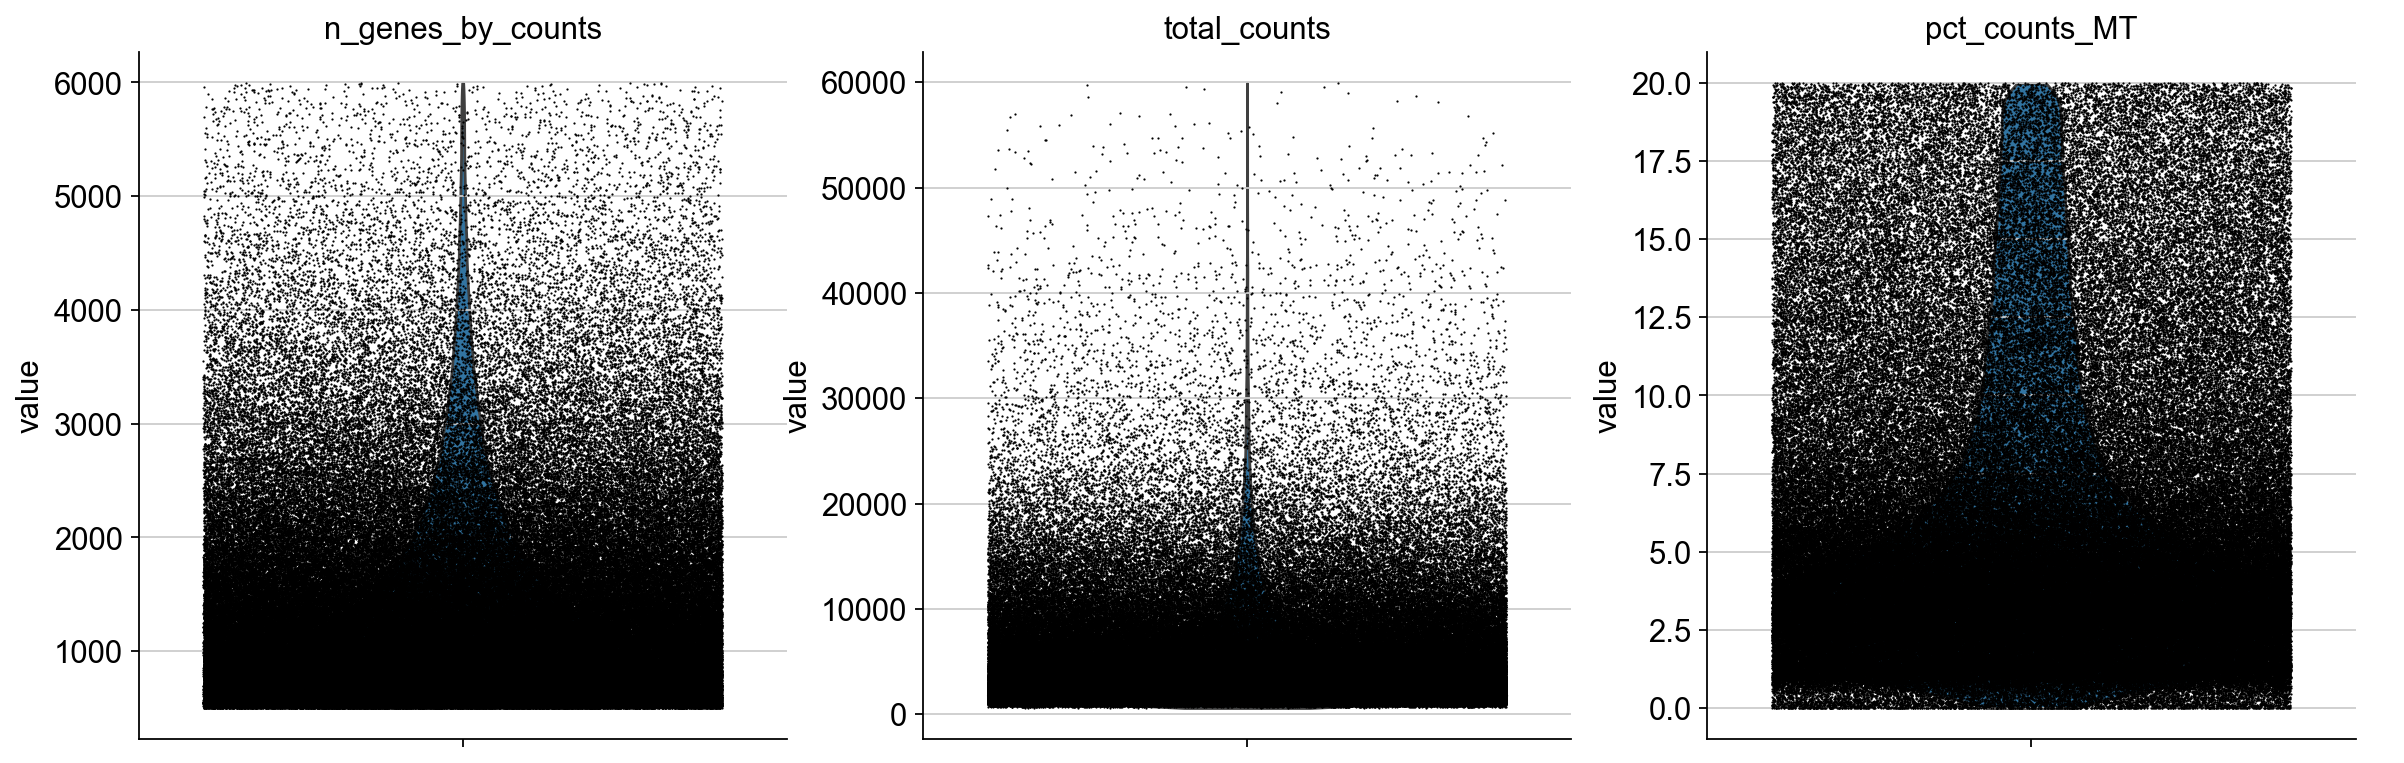

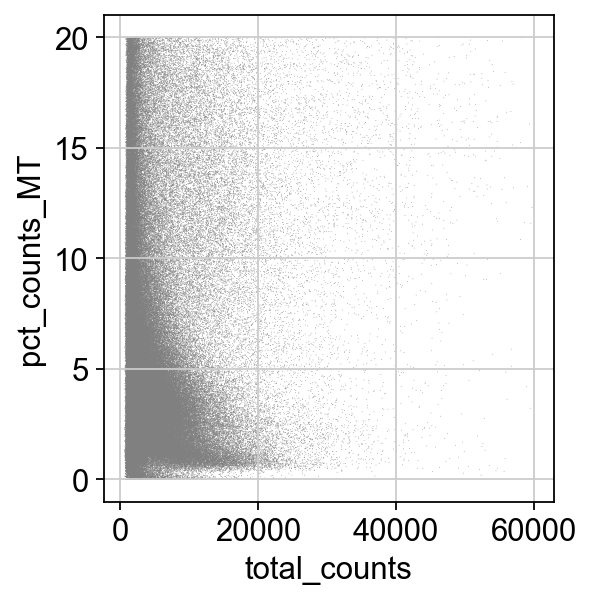

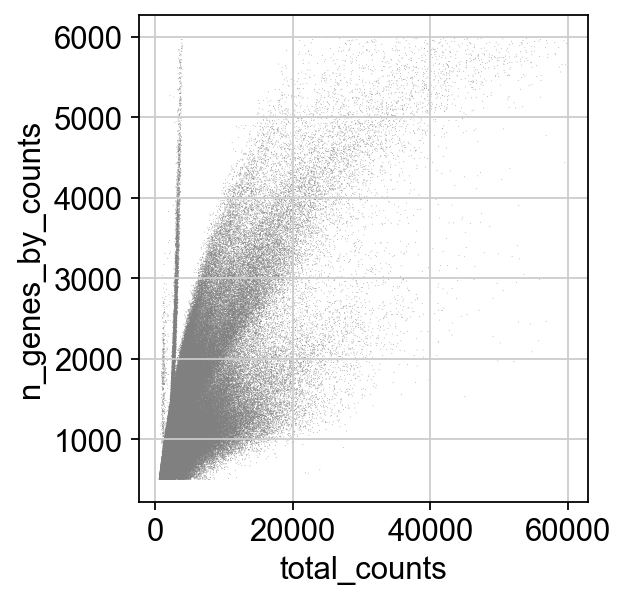

In [6]:
adata.var['MT'] = adata.var_names.str.startswith('MT-') 
sc.pp.calculate_qc_metrics(adata, qc_vars=['MT'], percent_top=None, log1p=False, inplace=True)
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_MT'],
             jitter=0.4, multi_panel=True)
sc.pl.scatter(adata, x='total_counts', y='pct_counts_MT')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

In [8]:
sc.pp.filter_cells(adata, min_genes=500) 
sc.pp.filter_genes(adata, min_cells=3) 
adata = adata[adata.obs.n_genes_by_counts < 6000, :]
adata = adata[adata.obs.total_counts < 60000, :]
adata = adata[adata.obs.pct_counts_MT < 20, :]
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

filtered out 1297 genes that are detected in less than 3 cells


c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\preprocessing\_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


normalizing counts per cell
    finished (0:00:01)


In [10]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5,n_top_genes=2000, batch_key='Sample')

If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:25)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [12]:
adata.raw = adata
adata = adata[:, adata.var.highly_variable]
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_MT'])
sc.pp.scale(adata, max_value=10)

regressing out ['total_counts', 'pct_counts_MT']
    finished (0:05:55)


In [ ]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca(adata, color='ACTA2')
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

In [ ]:
import harmonypy as hm
dfd = ['Sample','class', 'RawData']
harmony_out = hm.run_harmony(adata.obsm['X_pca'], adata.obs,dfd) 
adata.obsm['X_pca_harmony'] = harmony_out.Z_corr.T

In [ ]:
adata.write("harmonypy.h5ad")